# Section 5 — Outlier Treatment and Final Clean Dataset 

## Overview
The final step applies **Tukey-based clipping** to the five variables flagged in Section 4, preserving rows while capping extremes at [Q1 − 1.5×IQR, Q3 + 1.5×IQR]. The cleaned dataset is exported to `data/processed/air_quality_clean.csv` with zero remaining missing values.

## Key Results

| Element | Before Cleaning | After Cleaning |
|---------|-----------------|----------------|
| Number of rows | 9,357 | 9,357 |
| Number of columns | 16 | 15 |
| Total missing values | 16,701 | 0 |
| Columns removed | — | NMHC(GT) (Section 2) |
| Variables imputed with mean or median | — | 12 columns (Section 2) |
| Variables imputed with KNNImputer | — | 12 numerical columns (k=5) |
| Variables treated for outliers | — | CO(GT), C6H6(GT), T, RH, AH |
| Output file | — | `data/processed/air_quality_clean.csv` |

## Learning Objectives
- Apply one justified outlier treatment strategy
- Compare dataset before and after full cleaning
- Export `air_quality_clean.csv`

## Your Decisions Log

| Step | Decision | Evidence (plot / table / stat) |
|------|----------|--------------------------------|
| Outlier treatment | Tukey clipping (`clip_tukey`) on 5 variables | Boxplots after treatment — cell 3 |
| Preserve rows | No row deletion; cap values only | 9,357 rows unchanged |
| Clipping bounds | Per-variable Q1/Q3 IQR thresholds | Section 4 bounds table |
| Before/after summary | Full pipeline comparison table | Comparison table — cell 4 |
| Export | Save cleaned CSV | `data/processed/air_quality_clean.csv` |
| Visual evidence | Post-treatment boxplots | `reports/figures/final_cleaning_boxplots.png` |

## Comparison Table

| Element | Before Cleaning | After Cleaning |
|---------|-----------------|----------------|
| Number of rows | 9,357 | 9,357 |
| Number of columns | 16 | 15 |
| Total missing values | 16,701 | 0 |
| Columns removed | NMHC(GT) | NMHC(GT) |
| Variables imputed with mean or median | 12 columns (Section 2) | 12 columns (Section 2) |
| Variables imputed with KNNImputer | 13 numerical columns | 12 numerical columns (k=5) |
| Variables treated for outliers | — | CO(GT), C6H6(GT), T, RH, AH |

## Tasks
- a) Apply outlier treatment (winsorization, clipping, or justified conservation)
- b) Generate boxplots after treatment
- c) Complete the comparison table above
- d) Save cleaned dataset to `data/processed/air_quality_clean.csv`

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from src.config import (
    RAW_DATA_PATH,
    MISSING_SENTINEL,
    MISSINGNESS_THRESHOLD,
    KNN_K_VALUES,
    PROCESSED_DATA_PATH,
    FIGURES_DIR,
)
from src.load_data import load_raw_air_quality, build_datetime
from src.missing_values import (
    replace_sentinel_with_nan,
    missing_summary,
    decide_column_action,
)
from src.knn_imputation import select_numerical_columns, knn_impute
from src.plot_style import apply_plot_style, style_table, PALETTE
from src.clean_pipeline import (
    treat_outliers,
    build_comparison_table,
    export_clean_dataset,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
apply_plot_style()

# --- Sections 1–4: rebuild pipeline ---
df = load_raw_air_quality(RAW_DATA_PATH)
df = build_datetime(df)
df = replace_sentinel_with_nan(df, sentinel=MISSING_SENTINEL)
df = df.dropna(subset=['Datetime']).reset_index(drop=True)
df_before = df.copy()

missing_df = missing_summary(df)
columns_to_remove = missing_df.loc[
    missing_df['missing_pct'].apply(
        lambda pct: decide_column_action(pct, MISSINGNESS_THRESHOLD)
    )
    == 'remove',
    'column',
].tolist()
df = df.drop(columns=columns_to_remove)

num_cols = select_numerical_columns(df)
df_after_imputation = knn_impute(df, num_cols, n_neighbors=KNN_K_VALUES[-1])

OUTLIER_COLUMNS = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH']
TREATMENT_METHOD = 'clip_tukey'

print(f'Pipeline ready: {df_before.shape} -> {df_after_imputation.shape}')
print(f'Removed columns: {columns_to_remove}')

Pipeline ready: (9357, 16) -> (9357, 15)
Removed columns: ['NMHC(GT)']


In [2]:
# Apply the chosen outlier strategy to the selected variables.
df_final = treat_outliers(df_after_imputation, OUTLIER_COLUMNS, method=TREATMENT_METHOD)
display(style_table(df_final[OUTLIER_COLUMNS].head()))

CO(GT),C6H6(GT),T,RH,AH
2.600000,11.900000,13.600000,48.900000,0.757800
2.000000,9.400000,13.300000,47.700000,0.725500
2.200000,9.000000,11.900000,54.000000,0.750200
2.200000,9.200000,11.000000,60.000000,0.786700
1.600000,6.500000,11.200000,59.600000,0.788800


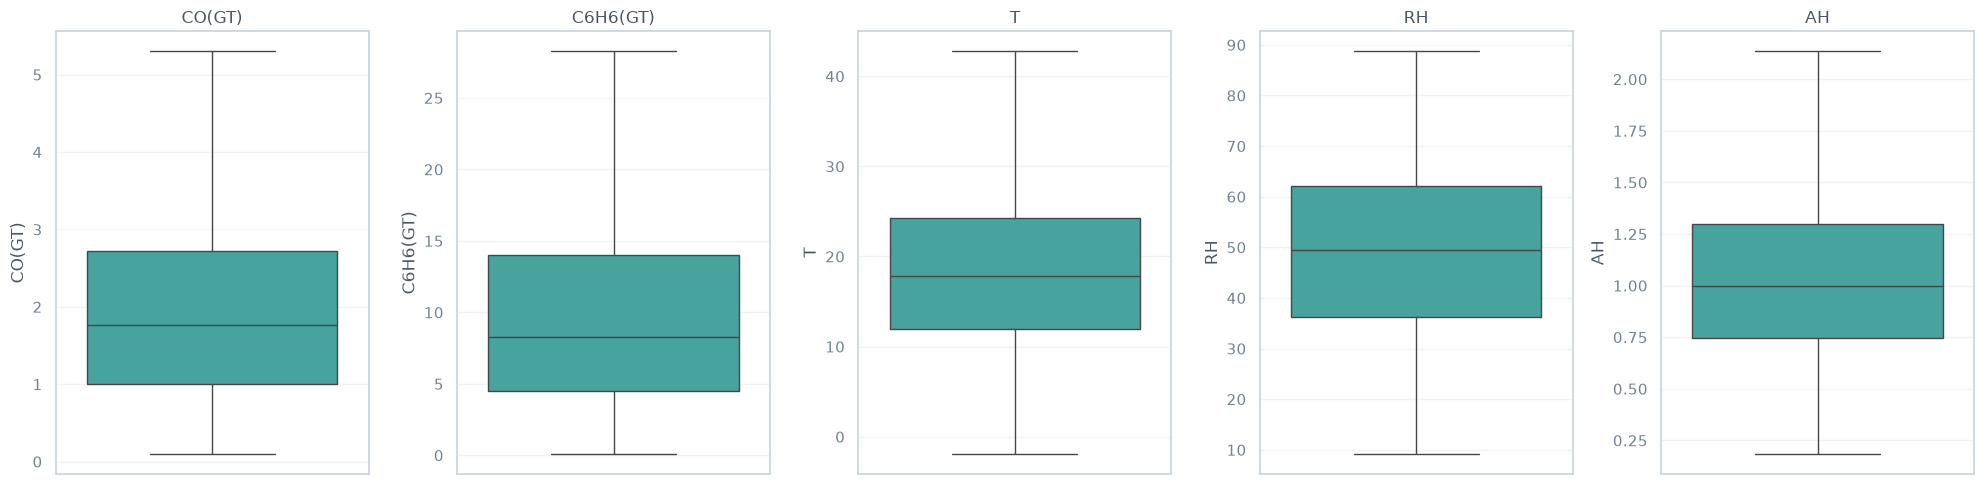

In [3]:
# Boxplots after treatment make the effect of clipping easy to see.
fig, axes = plt.subplots(1, len(OUTLIER_COLUMNS), figsize=(4 * len(OUTLIER_COLUMNS), 5))
if len(OUTLIER_COLUMNS) == 1:
    axes = [axes]

for axis, column in zip(axes, OUTLIER_COLUMNS):
    sns.boxplot(y=df_final[column], ax=axis, color=PALETTE['aqua_mid'])
    axis.set_title(column)
    axis.set_xlabel('')

fig.tight_layout()
fig.savefig(FIGURES_DIR / 'final_cleaning_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Build the comparison table with the decisions made in the previous steps.
comparison = build_comparison_table(
    df_before,
    df_final,
    metadata={
        'columns_removed': columns_to_remove,
        'mean_median_imputed': [
            'CO(GT)', 'NO2(GT)', 'NOx(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)',
            'PT08.S3(NOx)', 'PT08.S1(CO)', 'T', 'RH', 'PT08.S4(NO2)',
            'PT08.S5(O3)', 'AH',
        ],
        'knn_imputed': num_cols,
        'outlier_treated': OUTLIER_COLUMNS,
    },
)
display(style_table(comparison))

Element,Before Cleaning,After Cleaning
Number of rows,9357,9357
Number of columns,16,15
Total missing values,16701,0
Columns removed,None,NMHC(GT)
Variables imputed with mean or median,None,"CO(GT), NO2(GT), NOx(GT), C6H6(GT), PT08.S2(NMHC), PT08.S3(NOx), PT08.S1(CO), T, RH, PT08.S4(NO2), PT08.S5(O3), AH"
Variables imputed with KNNImputer,None,"CO(GT), PT08.S1(CO), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH"
Variables treated for outliers,None,"CO(GT), C6H6(GT), T, RH, AH"


In [5]:
# Export the final cleaned dataset (Section 5d).
export_clean_dataset(df_final, PROCESSED_DATA_PATH)
export_clean_dataset(df_final, PROJECT_ROOT / 'air_quality_clean.csv')
print(f'Saved to {PROCESSED_DATA_PATH}')
print(f'Saved to {PROJECT_ROOT / "air_quality_clean.csv"}')

Saved to /home/jose/Documentos/GitHub/Urban-Air-Quality-Data-Analysis/data/processed/air_quality_clean.csv
Saved to /home/jose/Documentos/GitHub/Urban-Air-Quality-Data-Analysis/air_quality_clean.csv


## Guiding Questions

1. **What changed the most after the complete cleaning process?**

   The biggest changes were the removal of invalid missing-value sentinels, the imputation of incomplete records, and the treatment of outliers. As a result, the distributions became cleaner and less extreme.

2. **Did the final dataset preserve the original information reasonably well?**

   Yes, reasonably well. The core structure and relationships are still there, but some rare extremes and variability were smoothed out during cleaning.

3. **What risks could appear if these cleaning steps were applied automatically without analysis?**

   Automatic cleaning can remove genuine pollution peaks, distort distributions, and introduce bias if the thresholds or imputation rules do not match the behavior of the sensors or the data.